Mini-project: simple neural network on MNIST dataset

Understand MNIST dataset + prepare inputs for a neural network

In [1]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


Load MNIST and convert images to tensors:

In [3]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

Inspect the dataset:

In [4]:
print(len(train_dataset))  # should be 60000

image, label = train_dataset[0]

print(image.shape)  # (1, 28, 28)
print(label)        # 0–9

60000
torch.Size([1, 28, 28])
5


What that means:
- 60000 is the number of training samples (images)
- 1 is the number of channels (greyscale)
- 28 x 28 is the image size

This is our input X.

Visualize samples:

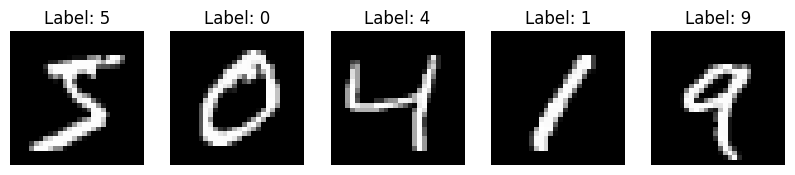

In [5]:
fig, ax = plt.subplots(1, 5, figsize=(10, 2))

for i in range(5):
    img, lbl = train_dataset[i]
    ax[i].imshow(img.squeeze(), cmap="gray")
    ax[i].set_title(f"Label: {lbl}")
    ax[i].axis("off")

plt.show()

Create DataLoader: this is how we feed batches to the model.

In [6]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

Inspect one batch:

In [7]:
images, labels = next(iter(train_loader))

print(images.shape)  # (32, 1, 28, 28)
print(labels.shape)  # (32,)

torch.Size([32, 1, 28, 28])
torch.Size([32])


How to interpret this:
- 32: batch size
- 1: number of channels
- 28 x 28: image size

So shape for a single batch is: (batch_size, channels, height, width) = (32, 1, 28, 28)

60000 / 32 means there are 1875 batches per epoch (1 epoch = one full pass over dataset = seeing all 60,000 images once)

Flatten images: neural networks expect vectors, not images

In [8]:
# images_flat = images.view(32, -1)
images_flat = images.view(images.size(0), -1) # more robust version (works for any batch size, not just 32)

print(images_flat.shape)  # (32, 784)

# manual flatten just for understanding — model already handles it

torch.Size([32, 784])


28 × 28 = 784 features so flatten shape is (batch_size, height x width) = (32, 28 x 28 = 784) 

-> This is our input vector X.

Summary:
- Dataset: 60,000 training images
- Input shape: (1, 28, 28)
- Batch shape: (32, 1, 28, 28)
- Flattened input: (32, 784)
- Each image = 784 features

Next: seeing images -> model -> logits -> loss

Build simple MLP model:

In [9]:
import torch
import torch.nn as nn

model = nn.Sequential(
    nn.Flatten(),               # no need to flatten manually
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)           # final output size is 10 because digits are 0-9
).to(device)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)


What this does:
- nn.Flatten() turns each 28 x 28 image into a vector of size 784 (the step we did earlier is done in the model so we don't have to do it manually)
- nn.Linear(28 * 28, 128) maps input to 128 hidden units
- nn.ReLU() adds nonlinearity (remember: without activation functions, the entire network would be equivalent to a single linear function, no matter how many layers → cannot learn complex patterns!)
- nn.Linear(128, 10) outputs 10 scores, one per digit class -> important: the final output is 10 logits, not probabilities.

Take one batch from the dataloader:

In [10]:
images, labels = next(iter(train_loader))

print("images shape before sending to device:", images.shape)
print("labels shape before sending to device:", labels.shape)

images = images.to(device)
labels = labels.to(device)

print("images shape:", images.shape)
print("labels shape:", labels.shape)
print("first 10 labels:", labels[:10])

images shape before sending to device: torch.Size([32, 1, 28, 28])
labels shape before sending to device: torch.Size([32])
images shape: torch.Size([32, 1, 28, 28])
labels shape: torch.Size([32])
first 10 labels: tensor([2, 3, 6, 3, 9, 7, 7, 5, 2, 7], device='mps:0')


What we see here:
- For MNIST, images.shape is usually: [batch_size, 1, 28, 28] = torch.Size([32, 1, 28, 28])
- and labels: [batch_size] = torch.Size([32])

We move tensors to a device (CPU/GPU) so that computations happen on that device. 

All tensors and the model must be on the same device; otherwise, PyTorch will raise an error.

Run a forward pass = compute predictions:

In [11]:
outputs = model(images)

print("output shape:", outputs.shape)
print(outputs[:2])

output shape: torch.Size([32, 10])
tensor([[-0.0970, -0.0829,  0.0403, -0.1613, -0.0216,  0.0966, -0.0724, -0.0755,
         -0.0556,  0.0337],
        [-0.1401, -0.2237,  0.2071, -0.1929, -0.1501, -0.0089, -0.0621, -0.1534,
         -0.0220, -0.1216]], device='mps:0', grad_fn=<SliceBackward0>)


The output shape is [batch_size, 10]: each row contains 10 raw scores for one image.

Get predicted classes: even before training we can check what class the model picks

In [12]:
preds = torch.argmax(outputs, dim=1)

print("predicted classes:", preds[:10])
print("true labels:      ", labels[:10])

predicted classes: tensor([5, 2, 2, 2, 5, 2, 2, 2, 2, 2], device='mps:0')
true labels:       tensor([2, 3, 6, 3, 9, 7, 7, 5, 2, 7], device='mps:0')


Very random for now, which is normal.

Compute the loss:

For multiclass classification like MNIST, use CrossEntropyLoss.

In [13]:
criterion = nn.CrossEntropyLoss()
loss = criterion(outputs, labels)

print("loss:", loss.item())

loss: 2.309201955795288


Important: nn.CrossEntropyLoss() expects:
- raw logits of shape [batch_size, num_classes]
- integer labels of shape [batch_size]

So do not apply softmax before the loss.

Inspect probabilities for one image:

In [14]:
probs = torch.softmax(outputs, dim=1)

print("probabilities for first image:")
print(probs[0])
print("sum:", probs[0].sum().item())
print("predicted class:", torch.argmax(probs[0]).item())
print("true label:", labels[0].item())

probabilities for first image:
tensor([0.0942, 0.0955, 0.1080, 0.0883, 0.1015, 0.1143, 0.0965, 0.0962, 0.0981,
        0.1073], device='mps:0', grad_fn=<SelectBackward0>)
sum: 0.9999999403953552
predicted class: 5
true label: 2


tensor([0.1055, 0.1124, 0.0995, ..., 0.1103]) is a probability distribution over the 10 digits (0 to 9):

| index | meaning | probability |
|-------|---------|-------------|
| 0     | digit 0 | 0.1055      |
| 1     | digit 1 | 0.1124      |
| 2     | digit 2 | 0.1068      |
| ...   | ...     | ...         |
| 9     | digit 9 | 0.1103      |

How to read it: the model is saying "I think this image is..." 
- 11.2% for digit 1 (highest)
- 11.0% for digit 9
- ~10% for everything else

Why prediction = 1: torch.argmax(probs[0]) picks the highest probability and here 0.1124 (index 1) = highest

Plotting a few images with true and predicted labels:

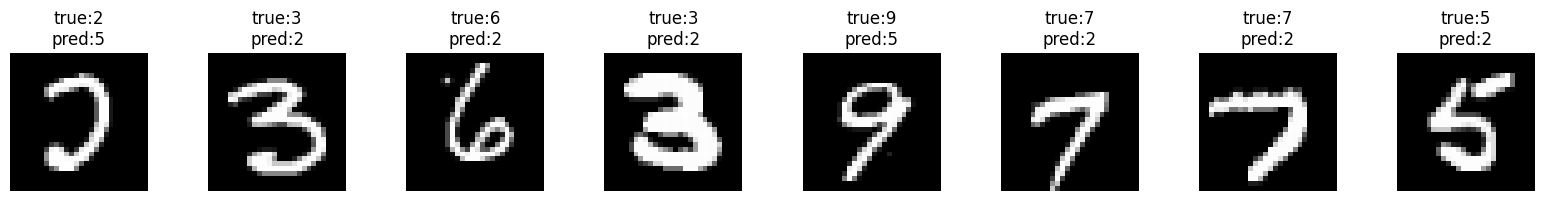

In [15]:
import matplotlib.pyplot as plt

images_cpu = images[:8].cpu()
labels_cpu = labels[:8].cpu()
preds_cpu = preds[:8].cpu()

fig, axes = plt.subplots(1, 8, figsize=(16, 2))

for i, ax in enumerate(axes):
    ax.imshow(images_cpu[i].squeeze(), cmap="gray")
    ax.set_title(f"true:{labels_cpu[i].item()}\npred:{preds_cpu[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Next: add optimizer

In [16]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

1 epoch training loop:

In [17]:
# Move model to GPU (or CPU if no GPU available)
model.to(device)

# Set model to training mode (important for layers like dropout or batchnorm later)
model.train()

# Initialize tracking variables
running_loss = 0.0   # accumulate loss over all batches
correct = 0          # count correct predictions
total = 0            # count total samples

printed_grads = False # set to True to print gradients

# Loop over batches of data
for images, labels in train_loader:

    # Move data to same device as model
    images = images.to(device)
    labels = labels.to(device)

    # Reset gradients from previous step (PyTorch accumulates gradients by default)
    optimizer.zero_grad()

    # FORWARD PASS: input -> model -> predictions (logits)
    logits = model(images)

    # Compute loss between predictions and true labels
    loss = criterion(logits, labels)

    # BACKWARD PASS: compute gradients of loss w.r.t ALL model parameters
    loss.backward()

    # print gradients
    if not printed_grads:
        print("Gradients after loss.backward():")
        for name, param in model.named_parameters():
            if param.grad is not None:
                print(name, param.grad.shape, param.grad.norm().item())
        printed_grads = True

    # UPDATE STEP: use gradients to update weights (gradient descent step)
    optimizer.step()

    # Accumulate loss (convert tensor to Python float)
    running_loss += loss.item()

    # Get predicted class (highest logit)
    preds = logits.argmax(dim=1)

    # Count how many predictions are correct
    correct += (preds == labels).sum().item()

    # Count total number of samples processed
    total += labels.size(0)


# Average loss over all batches
epoch_loss = running_loss / len(train_loader)

# Compute accuracy over all samples
epoch_acc = correct / total

# Print results
print(f"Epoch loss: {epoch_loss:.4f}")
print(f"Epoch accuracy: {epoch_acc:.4f}")

Gradients after loss.backward():
1.weight torch.Size([128, 784]) 0.9390946626663208
1.bias torch.Size([128]) 0.09930206835269928
3.weight torch.Size([10, 128]) 0.37357276678085327
3.bias torch.Size([10]) 0.23043985664844513
Epoch loss: 0.2916
Epoch accuracy: 0.9174


What we see:
- all trainable parameters have gradients
- gradient shapes match parameter shapes
- loss.backward() is computing them for the whole model and fills param.grad

Our 1 epoch training training also worked well: loss = 0.1295 and accuracy = 0.9623 

That means the training loop is functioning and learning fast.

Check activation:

Reminder: our model is

(0): Flatten(start_dim=1, end_dim=-1)

(1): Linear(in_features=784, out_features=128, bias=True)

(2): ReLU()

(3): Linear(in_features=128, out_features=10, bias=True)

In [18]:
images, labels = next(iter(train_loader))
images = images.to(device)

z1 = model[1](model[0](images)) # linear output
a1 = model[2](z1)               # after ReLU

print("z1 min/max:", z1.min().item(), z1.max().item())
print("a1 min/max:", a1.min().item(), a1.max().item())

z1 min/max: -13.94460391998291 8.597832679748535
a1 min/max: 0.0 8.597832679748535


Before ReLU: z1 contains both negative and positive values => That’s what a linear layer should produce.

After ReLU: a1 contains zero for everything that was negative and unchanged positive values

That’s exactly what ReLU does: $\mathrm{ReLU}(z) = \max(0, z)$

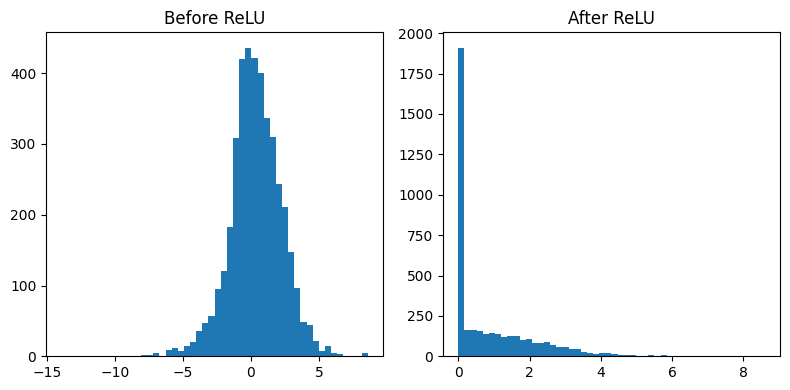

In [19]:
f, ax = plt.subplots(1, 2, figsize=(8,4))

ax[0].hist(z1.detach().cpu().numpy().ravel(), bins=50)
ax[0].set_title("Before ReLU")

ax[1].hist(a1.detach().cpu().numpy().ravel(), bins=50)
ax[1].set_title("After ReLU")

plt.tight_layout()
plt.show()

Left: Before ReLU

The distribution spreads across negative and positive values. That shows the linear layer is producing a full range of pre-activations.

Right: After ReLU

There is a big spike at 0. That means many neurons had negative pre-activation: ReLU set them to zero. The rest of the distribution is only positive


Make a second model with no ReLU activation:

In [20]:
model_no_relu = nn.Sequential(
    nn.Flatten(),               # no need to flatten manually
    nn.Linear(28 * 28, 128),
    # nn.ReLU(), # REMOVED
    nn.Linear(128, 10)           # final output size is 10 because digits are 0-9
).to(device)

print(model_no_relu)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): Linear(in_features=128, out_features=10, bias=True)
)


Then take a fresh optimizer and train for 1 epoch like before:

In [21]:
optimizer_no_relu = torch.optim.Adam(model_no_relu.parameters(), lr=1e-3)

In [22]:
model_no_relu.train()

running_loss_no_relu = 0.0
correct_no_relu = 0
total_no_relu = 0

for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer_no_relu.zero_grad()
    logits = model_no_relu(images)
    loss = criterion(logits, labels)
    loss.backward()
    optimizer_no_relu.step()

    running_loss_no_relu += loss.item()
    preds = logits.argmax(dim=1)
    correct_no_relu += (preds == labels).sum().item()
    total_no_relu += labels.size(0)

epoch_loss_no_relu = running_loss_no_relu / len(train_loader)
epoch_acc_no_relu = correct_no_relu / total_no_relu

print(f"No ReLU - loss: {epoch_loss_no_relu:.4f}")
print(f"No ReLU - accuracy: {epoch_acc_no_relu:.4f}")

No ReLU - loss: 0.3636
No ReLU - accuracy: 0.8978


Compare performance with and without ReLU:

In [23]:
print(f"With ReLU    - loss: {epoch_loss:.4f}, acc: {epoch_acc:.4f}")
print(f"Without ReLU - loss: {epoch_loss_no_relu:.4f}, acc: {epoch_acc_no_relu:.4f}")

With ReLU    - loss: 0.2916, acc: 0.9174
Without ReLU - loss: 0.3636, acc: 0.8978


After 1 epoch of training:

- With ReLU:
  - loss = 0.1295
  - accuracy = 0.9623

- Without ReLU:
  - loss = 0.3624
  - accuracy = 0.8978

The model with ReLU learns faster and achieves better performance.

Without ReLU, the model becomes a composition of linear layers, which is equivalent to a single linear transformation.  
It cannot capture complex patterns in the data, leading to worse performance.

Even after only one epoch, the difference is already significant, highlighting the importance of non-linearity in neural networks.

Next: train the full model for 10 epochs

Goal:
- train the MLP for multiple epochs
- track training loss and training accuracy
- visualize learning curves

This helps us see whether the model is learning steadily over time.

First we need to refresh the model for cleaner learning curves:

In [24]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

We just take our loop we wrote above for 1 epoch and loop over more epochs, and store loss and accuracy in order to plot them later:

In [25]:
num_epochs = 10

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch {epoch+1}/{num_epochs} - loss: {epoch_loss:.4f} - acc: {epoch_acc:.4f}")

Epoch 1/10 - loss: 0.2954 - acc: 0.9181
Epoch 2/10 - loss: 0.1269 - acc: 0.9630
Epoch 3/10 - loss: 0.0851 - acc: 0.9744
Epoch 4/10 - loss: 0.0631 - acc: 0.9810
Epoch 5/10 - loss: 0.0485 - acc: 0.9852
Epoch 6/10 - loss: 0.0376 - acc: 0.9882
Epoch 7/10 - loss: 0.0307 - acc: 0.9904
Epoch 8/10 - loss: 0.0250 - acc: 0.9923
Epoch 9/10 - loss: 0.0196 - acc: 0.9940
Epoch 10/10 - loss: 0.0171 - acc: 0.9948


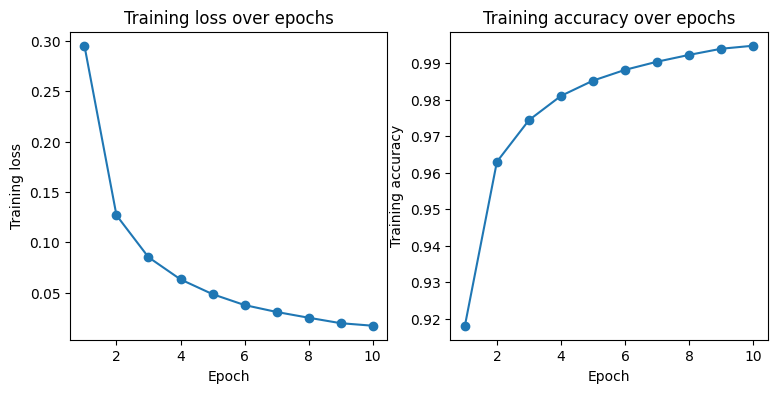

In [26]:
f, ax = plt.subplots(1, 2, figsize=(9, 4))

ax[0].plot(range(1, num_epochs + 1), train_losses, marker="o")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Training loss")
ax[0].set_title("Training loss over epochs")

ax[1].plot(range(1, num_epochs + 1), train_accuracies, marker="o")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Training accuracy")
ax[1].set_title("Training accuracy over epochs")

plt.show()

- The training loss decreases smoothly over epochs, showing that the model is learning to reduce prediction error and indicating successful optimization.
- The training accuracy increases over epochs, showing that predictions improve as weights are updated and strong model performance.
- The rapid improvement in early epochs reflects fast learning from gradient descent and the plateau suggests the model is converging.
- Together, these curves confirm that gradient-based optimization is working properly.

This confirms that:
- backpropagation is working
- the optimizer is effective
- mini-batch training enables efficient learning

Right now we only have a training set. Let's change that and add a validation set:

In [27]:
from torch.utils.data import random_split

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

 Training -> shuffle=True

During training, we want different mini-batches every epoch:
- Prevents the model from memorizing order patterns
- Improves generalization
- Makes gradient updates more stable and unbiased

Validation -> shuffle=False

For validation, we want consistent and reproducible evaluation:
- No learning happening → order doesn’t matter for optimization
- But we want stable metrics
So if we shuffle:
- accuracy might slightly fluctuate
- harder to debug / compare runs

Then we need to modify our training loop to track validation variables:

In [28]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [29]:
num_epochs = 10

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    
    # Training loop
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    # Validation loop
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():  # disable gradients (we don't train on the validation set)
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            # We just do a forward pass and compute the loss and accuracy
            logits = model(images)
            loss = criterion(logits, labels)

            val_loss += loss.item()

            preds = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)


    print(f"Epoch {epoch+1}/{num_epochs} "
      f"- train loss: {epoch_loss:.4f}, acc: {epoch_acc:.4f} "
      f"- val loss: {val_loss:.4f}, acc: {val_acc:.4f}")

Epoch 1/10 - train loss: 0.3245, acc: 0.9099 - val loss: 0.1813, acc: 0.9476
Epoch 2/10 - train loss: 0.1445, acc: 0.9580 - val loss: 0.1267, acc: 0.9629
Epoch 3/10 - train loss: 0.0980, acc: 0.9716 - val loss: 0.1062, acc: 0.9663
Epoch 4/10 - train loss: 0.0738, acc: 0.9769 - val loss: 0.0998, acc: 0.9696
Epoch 5/10 - train loss: 0.0565, acc: 0.9836 - val loss: 0.0888, acc: 0.9728
Epoch 6/10 - train loss: 0.0440, acc: 0.9863 - val loss: 0.0895, acc: 0.9722
Epoch 7/10 - train loss: 0.0355, acc: 0.9891 - val loss: 0.0892, acc: 0.9745
Epoch 8/10 - train loss: 0.0275, acc: 0.9920 - val loss: 0.0843, acc: 0.9760
Epoch 9/10 - train loss: 0.0220, acc: 0.9938 - val loss: 0.1003, acc: 0.9723
Epoch 10/10 - train loss: 0.0177, acc: 0.9948 - val loss: 0.0979, acc: 0.9747


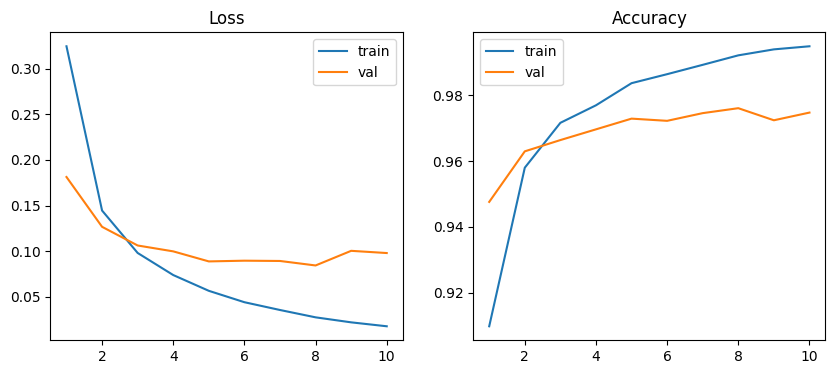

In [38]:
f, ax = plt.subplots(1, 2, figsize=(10, 4))

# Loss
ax[0].plot(range(1, num_epochs + 1), train_losses, label="train", color='tab:blue')
ax[0].plot(range(1, num_epochs + 1), val_losses, label="val", color='tab:orange')
ax[0].set_title("Loss")
ax[0].legend()

# Accuracy
ax[1].plot(range(1, num_epochs + 1), train_accuracies, label="train", color='tab:blue')
ax[1].plot(range(1, num_epochs + 1), val_accuracies, label="val", color='tab:orange')
ax[1].set_title("Accuracy")
ax[1].legend()

plt.show()

Train keeps improving:
- Loss keeps decreasing smoothly (0.43 to 0.026)
- Accuracy keeps increasing (0.88 to 0.993)

The model is clearly learning very well

Val stops improving (around epoch 6–7):
- Loss decreases until ~epoch 6, then plateaus / slightly fluctuates
- Accuracy improves early, then stagnates around ~0.96–0.965

Around epoch 6–7 is our turning point:
- Before: model is learning useful patterns
- After: model is memorizing training data more than generalizing

Summary: 

The model learns effectively during the first epochs, as both training and validation loss decrease.
After around epoch 6, validation performance saturates while training performance continues to improve, indicating the onset of overfitting.
The model begins to memorize training data rather than improving generalization.

Solutions:
- early stopping: stop training at epoch ~6–7
- more data
- regularization (dropout or weight decay)

Next: add dropout and compare with baseline

Goal:
- add dropout to the MLP
- train with the same train/validation split
- compare train vs validation curves
- check whether dropout reduces overfitting

In [ ]:
model_dropout = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Dropout(p=0.5), # strong dropout rate to see effect clearly
    nn.Linear(128, 10)
).to(device)

print(model_dropout)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=128, out_features=10, bias=True)
)


In [32]:
criterion = nn.CrossEntropyLoss()
optimizer_dropout = torch.optim.Adam(model_dropout.parameters(), lr=1e-3)

In [33]:
num_epochs = 10

train_losses_dropout = []
train_accuracies_dropout = []
val_losses_dropout = []
val_accuracies_dropout = []

for epoch in range(num_epochs):

    # Training
    model_dropout.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer_dropout.zero_grad()
        logits = model_dropout(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer_dropout.step()

        running_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    train_losses_dropout.append(epoch_loss)
    train_accuracies_dropout.append(epoch_acc)

    # Validation
    model_dropout.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model_dropout(images)
            loss = criterion(logits, labels)

            val_loss += loss.item()
            preds = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    val_losses_dropout.append(val_loss)
    val_accuracies_dropout.append(val_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"- train loss: {epoch_loss:.4f}, acc: {epoch_acc:.4f} "
        f"- val loss: {val_loss:.4f}, acc: {val_acc:.4f}"
    )

Epoch 1/10 - train loss: 0.4390, acc: 0.8731 - val loss: 0.1963, acc: 0.9440
Epoch 2/10 - train loss: 0.2456, acc: 0.9276 - val loss: 0.1479, acc: 0.9571
Epoch 3/10 - train loss: 0.1963, acc: 0.9426 - val loss: 0.1281, acc: 0.9610
Epoch 4/10 - train loss: 0.1780, acc: 0.9478 - val loss: 0.1123, acc: 0.9662
Epoch 5/10 - train loss: 0.1603, acc: 0.9514 - val loss: 0.1028, acc: 0.9680
Epoch 6/10 - train loss: 0.1502, acc: 0.9542 - val loss: 0.1008, acc: 0.9692
Epoch 7/10 - train loss: 0.1372, acc: 0.9584 - val loss: 0.0973, acc: 0.9701
Epoch 8/10 - train loss: 0.1306, acc: 0.9591 - val loss: 0.0965, acc: 0.9712
Epoch 9/10 - train loss: 0.1234, acc: 0.9621 - val loss: 0.0896, acc: 0.9739
Epoch 10/10 - train loss: 0.1209, acc: 0.9628 - val loss: 0.0936, acc: 0.9723


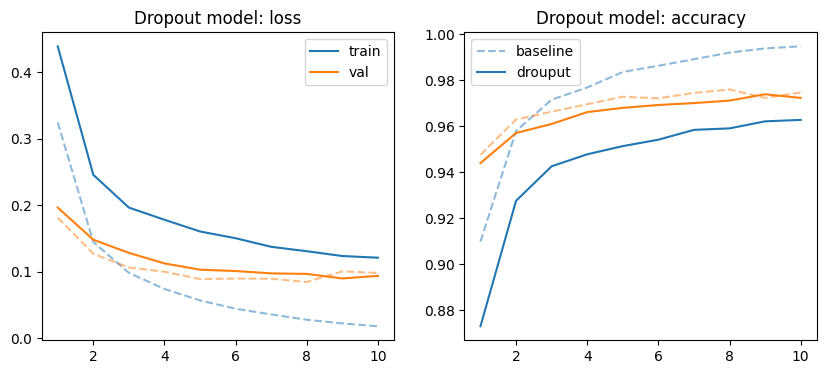

In [ ]:
f, ax = plt.subplots(1, 2, figsize=(10, 4))

# Loss
ax[0].plot(range(1, num_epochs + 1), train_losses, color='tab:blue', ls='dashed', alpha=0.5)
ax[0].plot(range(1, num_epochs + 1), val_losses, color='tab:orange', ls='dashed', alpha=0.5)

ax[0].plot(range(1, num_epochs + 1), train_losses_dropout, color='tab:blue', label="train")
ax[0].plot(range(1, num_epochs + 1), val_losses_dropout, color='tab:orange', label="val")

ax[0].set_title("Dropout model: loss")
ax[0].legend()

# Accuracy
ax[1].plot(range(1, num_epochs + 1), train_accuracies, label='baseline', color='tab:blue', ls='dashed', alpha=0.5)
ax[1].plot(range(1, num_epochs + 1), val_accuracies, color='tab:orange', ls='dashed', alpha=0.5)

ax[1].plot(range(1, num_epochs + 1), train_accuracies_dropout, label="drouput", color='tab:blue')
ax[1].plot(range(1, num_epochs + 1), val_accuracies_dropout, color='tab:orange')

ax[1].set_title("Dropout model: accuracy")
ax[1].legend()

plt.show()

What we see:
- Training: dropout loss higher than baseline, accuracy lower than baseline. This is expected as dropout makes training harder
- Validation: both loss and accuracy close to baseline. That means we did not lose performance on validation set.
- The gap between train and validation gets smaller. This indicates better generalization.

This confirms that dropout helps prevent the model from relying too much on specific neurons.

Next: add L2 regularization (weight decay) and compare

Goal:
- add L2 regularization through weight decay
- train the same MLP with the same train/validation split
- compare train and validation curves with baseline and dropout models

In [52]:
model_l2 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

In [53]:
criterion = nn.CrossEntropyLoss()
optimizer_l2 = torch.optim.Adam(model_l2.parameters(), lr=1e-3, weight_decay=1e-3) # L2 is added through the optimizer

In [54]:
num_epochs = 10

train_losses_l2 = []
train_accuracies_l2 = []
val_losses_l2 = []
val_accuracies_l2 = []

for epoch in range(num_epochs):

    # Training
    model_l2.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer_l2.zero_grad()
        logits = model_l2(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer_l2.step()

        running_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    train_losses_l2.append(epoch_loss)
    train_accuracies_l2.append(epoch_acc)

    # Validation
    model_l2.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model_l2(images)
            loss = criterion(logits, labels)

            val_loss += loss.item()
            preds = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    val_losses_l2.append(val_loss)
    val_accuracies_l2.append(val_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"- train loss: {epoch_loss:.4f}, acc: {epoch_acc:.4f} "
        f"- val loss: {val_loss:.4f}, acc: {val_acc:.4f}"
    )

Epoch 1/10 - train loss: 0.3421, acc: 0.9068 - val loss: 0.1978, acc: 0.9453
Epoch 2/10 - train loss: 0.1709, acc: 0.9520 - val loss: 0.1584, acc: 0.9559
Epoch 3/10 - train loss: 0.1343, acc: 0.9620 - val loss: 0.1406, acc: 0.9585
Epoch 4/10 - train loss: 0.1181, acc: 0.9668 - val loss: 0.1174, acc: 0.9654
Epoch 5/10 - train loss: 0.1090, acc: 0.9698 - val loss: 0.1161, acc: 0.9676
Epoch 6/10 - train loss: 0.1008, acc: 0.9720 - val loss: 0.1138, acc: 0.9668
Epoch 7/10 - train loss: 0.0975, acc: 0.9732 - val loss: 0.1133, acc: 0.9658
Epoch 8/10 - train loss: 0.0949, acc: 0.9743 - val loss: 0.1115, acc: 0.9679
Epoch 9/10 - train loss: 0.0910, acc: 0.9754 - val loss: 0.1146, acc: 0.9666
Epoch 10/10 - train loss: 0.0909, acc: 0.9752 - val loss: 0.1044, acc: 0.9690


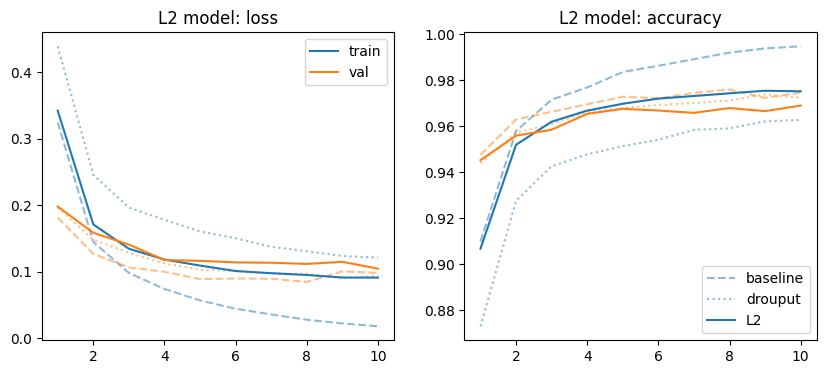

In [57]:
f, ax = plt.subplots(1, 2, figsize=(10, 4))

# Loss
ax[0].plot(range(1, num_epochs + 1), train_losses, color='tab:blue', ls='dashed', alpha=0.5)
ax[0].plot(range(1, num_epochs + 1), val_losses, color='tab:orange', ls='dashed', alpha=0.5)

ax[0].plot(range(1, num_epochs + 1), train_losses_dropout, color='tab:blue', ls='dotted', alpha=0.5)
ax[0].plot(range(1, num_epochs + 1), val_losses_dropout, color='tab:orange', ls='dotted', alpha=0.5)

ax[0].plot(range(1, num_epochs + 1), train_losses_l2, color='tab:blue', label="train")
ax[0].plot(range(1, num_epochs + 1), val_losses_l2, color='tab:orange', label="val")

ax[0].set_title("L2 model: loss")
ax[0].legend()

# Accuracy
ax[1].plot(range(1, num_epochs + 1), train_accuracies, label='baseline', color='tab:blue', ls='dashed', alpha=0.5)
ax[1].plot(range(1, num_epochs + 1), val_accuracies, color='tab:orange', ls='dashed', alpha=0.5)

ax[1].plot(range(1, num_epochs + 1), train_accuracies_dropout, label="drouput", color='tab:blue', ls='dotted', alpha=0.5)
ax[1].plot(range(1, num_epochs + 1), val_accuracies_dropout, color='tab:orange', ls='dotted', alpha=0.5)

ax[1].plot(range(1, num_epochs + 1), train_accuracies_l2, label="L2", color='tab:blue')
ax[1].plot(range(1, num_epochs + 1), val_accuracies_l2, color='tab:orange')

ax[1].set_title("L2 model: accuracy")
ax[1].legend()

plt.show()

What we see:
- Training loss: baseline > L2 > dropout  (in terms of fitting ability)
- Validation loss: baseline is the lowest at early epochs but overfits later. dropout is slightly lower but stable, L2 is in between. 

Dropout and L2 both reduce overfitting, but differently.

- Training accuracy: baseline highest, L2 a bit lower, dropout lowest
- Validation accuracy: Dropout ≈ Baseline ≥ L2

If we compare the gaps:
- baseline: big gap => overfitting
- dropout: small gap => best generalization
- L2: moderate gap => mid regularization (effect probabily weak because the neural network is to small / too simple)